# Paper Models - clean rebuild

Outcomes: SP volume difference, WM surface area difference.  
Predictors per paper: `GA`, `QA_diff`, `stack_count`, plus `sh_sp_diff` (subplate-mask homogeneity) or `cnr_diff` (boundary CR, SP↔IZ).

**Two split pairs (S1-S2, S3-S4) treated as independent replications**, fit separately. The right way to read the results is *consistency across pairs*, not which pair has the highest R².

Caveat to add to slide: `cnr_diff` is a Michelson contrast over morphologically-derived boundary bands at the SP↔IZ interface. It probes the SP segmentation boundary, so it's only an appropriate predictor for SP volume — **not** for WM surface area (different boundary). Boundary-handling refinement is in progress.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from slides_helpers import fit_and_present, model_comparison_table

DATA = Path('../data')
ASSETS = Path('../assets')
ASSETS.mkdir(exist_ok=True)

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

## Load data and build per-pair analysis frames

Three CSVs:
- `raw_subject_data.csv` — `stack_count`, `QA_S1..S4`, `QA12_mean`, `QA34_mean`, `GA`
- `split_comparision_data.csv` — per split-pair: `abs_diff_sp`, `rel_diff_sp`, `wm_surface_area_diff`, `wm_surface_area_mean`, `cnr_diff`, `cnr_mean`
- `image_quality_metrics.csv` — per split: `snr_subplate` (mean/SD within mask — surface homogeneity, NOT classical SNR), `sp_iz_cnr` (boundary CR — already aggregated to `cnr_diff`/`cnr_mean` above)

In [2]:
raw = pd.read_csv(DATA / 'raw_subject_data.csv')
splits_df = pd.read_csv(DATA / 'split_comparision_data.csv')
iqm = pd.read_csv(DATA / 'image_quality_metrics.csv')

print('raw:', raw.shape, '| splits:', splits_df.shape, '| iqm:', iqm.shape)

# QA differences within each pair (paper's 'quality difference')
raw['qa_diff_S1S2'] = (raw['QA_S1'] - raw['QA_S2']).abs()
raw['qa_diff_S3S4'] = (raw['QA_S3'] - raw['QA_S4']).abs()

# Surface-homogeneity (SH) differences within each pair, on subplate mask
sh_wide = iqm.pivot_table(
    index=['subject_id', 'session_id'],
    columns='split',
    values='snr_subplate',
).reset_index()
sh_wide['sh_sp_diff_S1S2'] = (sh_wide['S1'] - sh_wide['S2']).abs()
sh_wide['sh_sp_diff_S3S4'] = (sh_wide['S3'] - sh_wide['S4']).abs()
sh_wide = sh_wide[['subject_id', 'session_id', 'sh_sp_diff_S1S2', 'sh_sp_diff_S3S4']]

def build_pair(label):
    pair_tag = label.replace('-', '')  # 'S1S2'
    df = (
        splits_df[splits_df['split_pair'] == label]
        .merge(raw[['subject_id', 'session_id', 'stack_count',
                    f'qa_diff_{pair_tag}',
                    f'QA{pair_tag[1] + pair_tag[3]}_mean']],
               on=['subject_id', 'session_id'], how='left')
        .merge(sh_wide[['subject_id', 'session_id', f'sh_sp_diff_{pair_tag}']],
               on=['subject_id', 'session_id'], how='left')
        .rename(columns={f'qa_diff_{pair_tag}': 'qa_diff',
                         f'QA{pair_tag[1] + pair_tag[3]}_mean': 'qa_mean',
                         f'sh_sp_diff_{pair_tag}': 'sh_sp_diff'})
    )
    # APD (absolute percent difference) — paper's reliability metric
    df['apd_sp'] = df['rel_diff_sp']  # already computed as rel diff in pipeline
    df['apd_surface'] = (df['wm_surface_area_diff']
                          / df['wm_surface_area_mean'] * 100)
    return df

s12 = build_pair('S1-S2')
s34 = build_pair('S3-S4')

print('\nS1-S2 frame:', s12.shape)
print('S3-S4 frame:', s34.shape)
display(s12.head(3))

raw: (23, 11) | splits: (46, 16) | iqm: (92, 25)

S1-S2 frame: (23, 22)
S3-S4 frame: (23, 22)


,subject_id,session_id,GA,split_pair,abs_diff_sp,abs_diff_cp,abs_diff_inner,abs_diff_total,rel_diff_sp,rel_diff_cp,...,cnr_diff,cnr_mean,wm_surface_area_diff,wm_surface_area_mean,stack_count,qa_diff,qa_mean,sh_sp_diff,apd_sp,apd_surface
0,1109332,MR-EI_Fetal_Body-26810110-20230404,27.000,S1-S2,234.127,680.279,2088.988,1642.836,0.907,2.251,...,0.002,0.011,1035.265,17384.387,3,0.080,0.540,0.230,0.907,5.955
1,4712320,MR-EI_Fetal_Body-26831832-20230502,30.400,S1-S2,191.251,302.062,1019.166,1129.977,0.448,0.549,...,0.002,0.008,1624.870,28397.498,5,0.050,0.730,0.088,0.448,5.722
2,5552729,MR-EI_Fetal_Neuro-26149163-20210623,26.100,S1-S2,805.681,278.453,1965.108,2492.336,3.499,1.046,...,0.003,0.015,285.124,15146.900,11,0.090,0.610,0.722,3.499,1.882


## Layer 1 — Reliability magnitude (descriptive)

Paper-style summary: APD (mean ± SD, range) for both outcomes and both pairs.

In [3]:
def reliability_row(df, abs_col, apd_col, label, pair):
    a = df[abs_col].dropna()
    p = df[apd_col].dropna()
    return {
        'metric': label, 'pair': pair, 'N': len(a),
        'abs_mean': a.mean().round(2), 'abs_sd': a.std().round(2),
        'abs_range': f'[{a.min():.1f}, {a.max():.1f}]',
        'APD_mean': p.mean().round(2), 'APD_sd': p.std().round(2),
        'APD_range': f'[{p.min():.2f}, {p.max():.2f}]',
    }

rows = [
    reliability_row(s12, 'abs_diff_sp', 'apd_sp', 'SP volume (mm³)', 'S1-S2'),
    reliability_row(s34, 'abs_diff_sp', 'apd_sp', 'SP volume (mm³)', 'S3-S4'),
    reliability_row(s12, 'wm_surface_area_diff', 'apd_surface', 'WM surface area (mm²)', 'S1-S2'),
    reliability_row(s34, 'wm_surface_area_diff', 'apd_surface', 'WM surface area (mm²)', 'S3-S4'),
]
reliability_table = pd.DataFrame(rows)
reliability_table.to_csv(ASSETS / 'reliability_summary_table.csv', index=False)
display(reliability_table)
print('Saved → assets/reliability_summary_table.csv')

,metric,pair,N,abs_mean,abs_sd,abs_range,APD_mean,APD_sd,APD_range
0,SP volume (mm³),S1-S2,23,577.150,498.690,"[23.6, 1793.3]",1.610,1.380,"[0.07, 4.95]"
1,SP volume (mm³),S3-S4,23,588.190,597.750,"[1.6, 1799.5]",1.410,1.240,"[0.01, 4.00]"
2,WM surface area (mm²),S1-S2,23,207.880,380.330,"[0.6, 1624.9]",0.960,1.620,"[0.00, 5.96]"
3,WM surface area (mm²),S3-S4,23,152.930,153.710,"[4.2, 609.0]",0.650,0.730,"[0.03, 3.58]"


Saved → assets/reliability_summary_table.csv


## Volume models

Three specifications, each fit independently for S1-S2 and S3-S4:
1. **M_GA** (baseline): `vol_diff_sp ~ GA`
2. **M_SH** (paper-style + homogeneity): `vol_diff_sp ~ GA + qa_diff + stack_count + sh_sp_diff`
3. **M_CNR** (paper-style + boundary CR): `vol_diff_sp ~ GA + qa_diff + stack_count + cnr_diff`


===  | S1-S2 | R²=0.146 | F=3.59 | p=0.0722 | N=23 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-1462.215,1081.523,-1.350,0.191,-3711.360,786.930,
GA,71.497,37.759,1.890,0.072,-7.030,150.020,



===  | S3-S4 | R²=0.363 | F=11.97 | p=0.0023 | N=23 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-3269.306,1119.379,-2.920,0.008,-5597.180,-941.430,**
GA,135.237,39.081,3.460,0.002,53.960,216.510,**


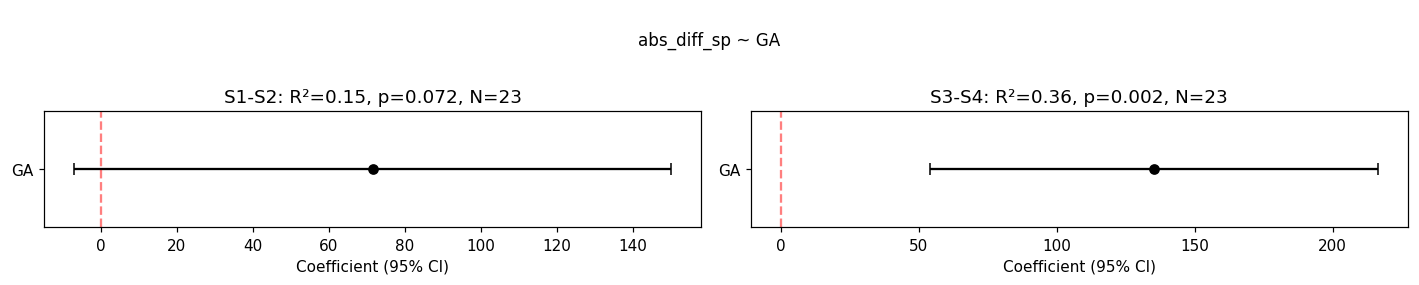

In [4]:
vol_results = {}

vol_results['M_GA (vol)'] = fit_and_present(
    'abs_diff_sp', ['GA'], s12, s34,
    '', 'vol_M_GA', ASSETS,
)


===  | S1-S2 | R²=0.284 | F=1.78 | p=0.1767 | N=23 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-1618.064,1142.239,-1.420,0.174,-4017.820,781.690,
GA,76.016,38.287,1.990,0.063,-4.420,156.450,
qa_diff,-1410.535,1326.197,-1.060,0.302,-4196.770,1375.700,
stack_count,-6.626,35.054,-0.190,0.852,-80.270,67.020,
sh_sp_diff,449.014,270.198,1.660,0.114,-118.650,1016.680,



===  | S3-S4 | R²=0.473 | F=4.03 | p=0.0165 | N=23 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-2954.946,1424.973,-2.070,0.053,-5948.700,38.810,
GA,109.656,45.625,2.400,0.027,13.800,205.510,*
qa_diff,2952.552,1526.898,1.930,0.069,-255.340,6160.450,
stack_count,22.710,37.401,0.610,0.551,-55.870,101.290,
sh_sp_diff,103.301,550.089,0.190,0.853,-1052.390,1258.990,


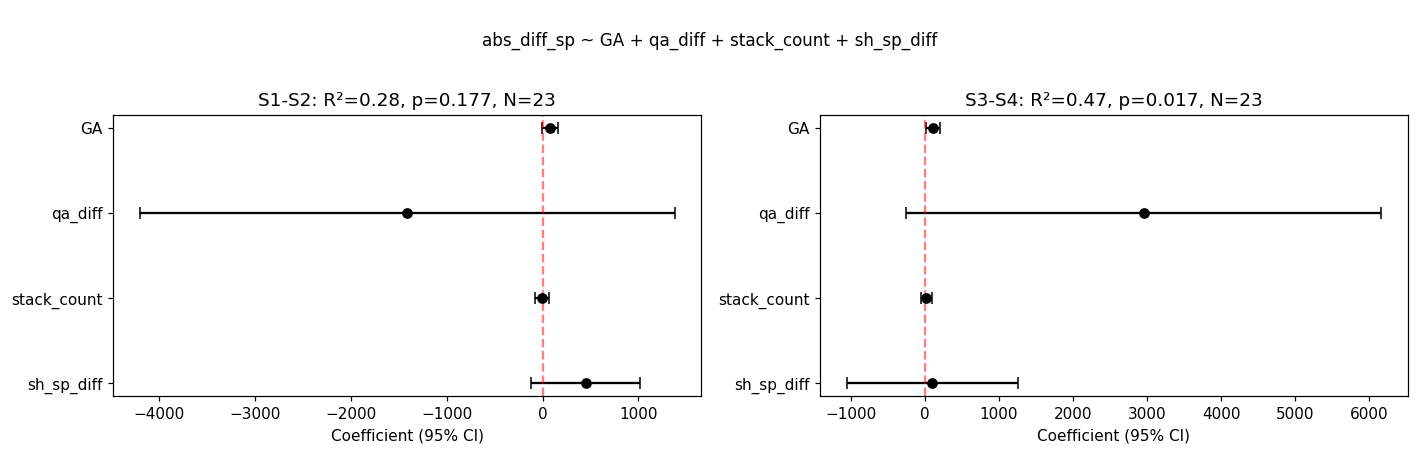

In [5]:
vol_results['M_SH (vol)'] = fit_and_present(
    'abs_diff_sp', ['GA', 'qa_diff', 'stack_count', 'sh_sp_diff'], s12, s34,
    '', 'vol_M_SH', ASSETS,
)


===  | S1-S2 | R²=0.222 | F=1.28 | p=0.3137 | N=23 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-1776.490,1199.467,-1.480,0.156,-4296.480,743.500,
GA,75.121,39.979,1.880,0.077,-8.870,159.110,
qa_diff,-761.734,1370.342,-0.560,0.585,-3640.720,2117.250,
stack_count,16.853,35.779,0.470,0.643,-58.320,92.020,
cnr_diff,104926.551,99454.210,1.060,0.305,-104018.990,313872.090,



===  | S3-S4 | R²=0.474 | F=4.05 | p=0.0163 | N=23 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-2775.730,1203.662,-2.310,0.033,-5304.530,-246.930,*
GA,106.873,41.749,2.560,0.020,19.160,194.580,*
qa_diff,2913.459,1515.689,1.920,0.071,-270.890,6097.800,
stack_count,18.518,37.605,0.490,0.628,-60.490,97.520,
cnr_diff,-18409.836,72958.751,-0.250,0.804,-171690.480,134870.810,


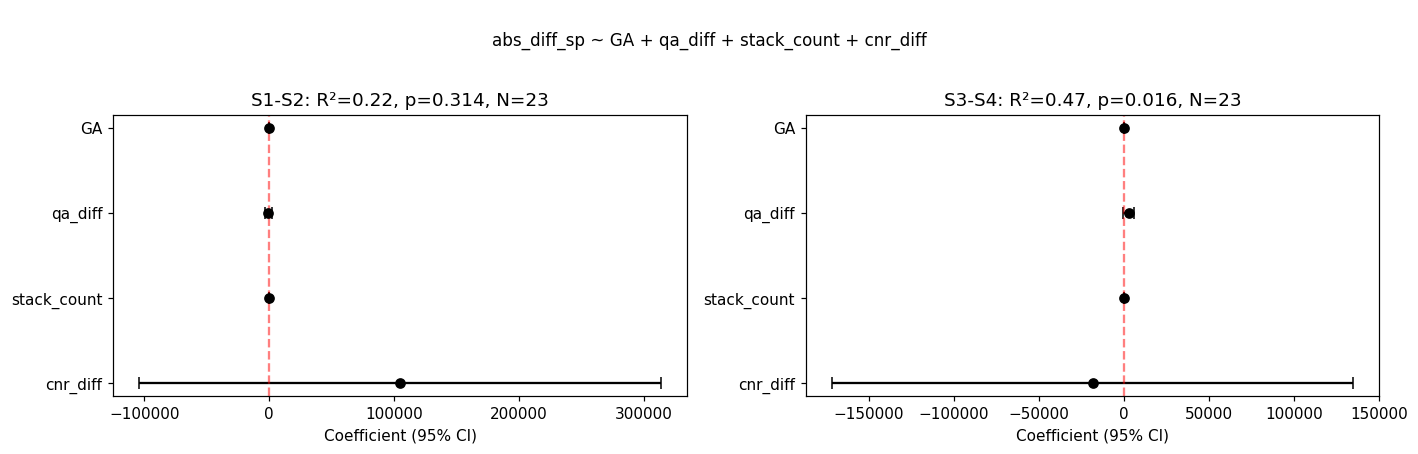

In [6]:
vol_results['M_CNR (vol)'] = fit_and_present(
    'abs_diff_sp', ['GA', 'qa_diff', 'stack_count', 'cnr_diff'], s12, s34,
    '', 'vol_M_CNR', ASSETS,
)

## Surface area models

Same structure, **without `cnr_diff`** (wrong boundary — `cnr_diff` is the SP↔IZ contrast, not the CP↔WM surface that the surface metric is extracted from). `sh_sp_diff` is included as a general image-homogeneity proxy; expected to be small.

1. **S_GA**: `wm_surface_area_diff ~ GA`
2. **S_acq**: `wm_surface_area_diff ~ GA + qa_diff + stack_count`


===  | S1-S2 | R²=0.009 | F=0.18 | p=0.6715 | N=23 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-172.718,888.566,-0.190,0.848,-2020.590,1675.160,
GA,13.343,31.022,0.430,0.671,-51.170,77.860,



===  | S3-S4 | R²=0.188 | F=4.88 | p=0.0385 | N=23 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-561.622,324.930,-1.730,0.099,-1237.350,114.110,
GA,25.051,11.344,2.210,0.038,1.460,48.640,*


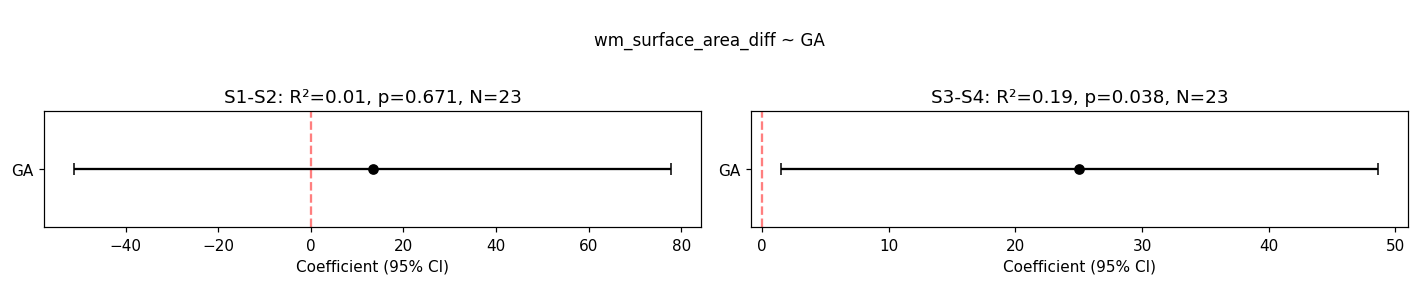

In [7]:
surf_results = {}

surf_results['S_GA (surf)'] = fit_and_present(
    'wm_surface_area_diff', ['GA'], s12, s34,
    '', 'surf_S_GA', ASSETS,
)


===  | S1-S2 | R²=0.132 | F=0.96 | p=0.4319 | N=23 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,218.380,933.495,0.230,0.818,-1735.450,2172.210,
GA,12.277,31.274,0.390,0.699,-53.180,77.730,
qa_diff,-1135.804,1062.611,-1.070,0.299,-3359.870,1088.270,
stack_count,-37.213,27.523,-1.350,0.192,-94.820,20.390,



===  | S3-S4 | R²=0.304 | F=2.76 | p=0.0703 | N=23 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-355.298,344.280,-1.030,0.315,-1075.880,365.290,
GA,22.116,11.991,1.840,0.081,-2.980,47.210,
qa_diff,-21.559,436.222,-0.050,0.961,-934.580,891.460,
stack_count,-17.719,10.441,-1.700,0.106,-39.570,4.130,


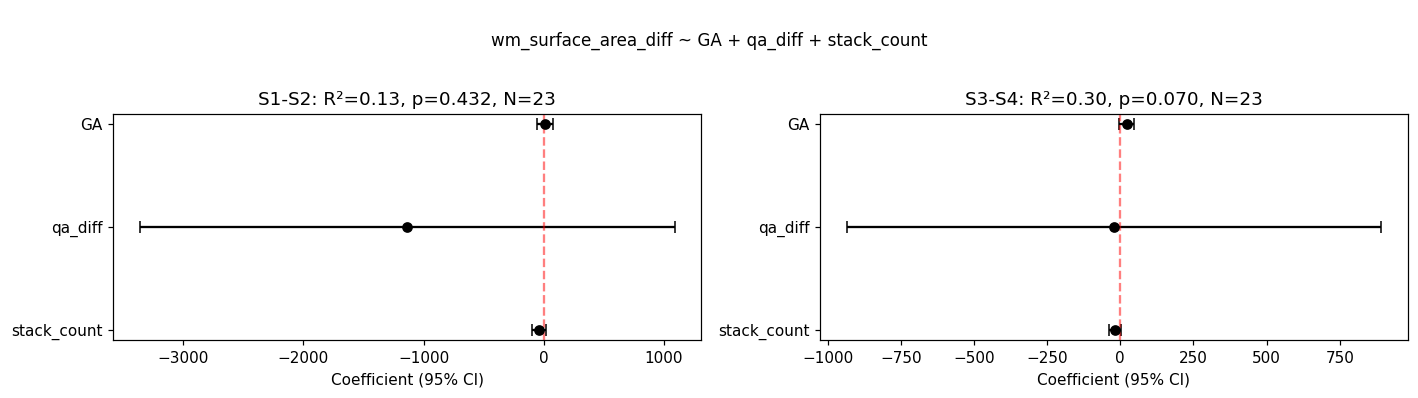

In [8]:
surf_results['S_acq (surf)'] = fit_and_present(
    'wm_surface_area_diff', ['GA', 'qa_diff', 'stack_count'], s12, s34,
    '', 'surf_S_acq', ASSETS,
)

## Cross-model comparison

Side-by-side R², GA effect across all six models × both pairs. Read column-wise: a model is *consistent* if its R², GA-sign, and GA-significance look similar across S1-S2 and S3-S4.

,model,pair,N,R2,adj_R2,F_p,GA_coef,GA_p
0,M_GA (vol),S1-S2,23,0.146,0.105,0.072,71.497,0.072
1,M_GA (vol),S3-S4,23,0.363,0.333,0.002,135.237,0.002
2,M_SH (vol),S1-S2,23,0.284,0.124,0.177,76.016,0.062
3,M_SH (vol),S3-S4,23,0.473,0.356,0.017,109.656,0.027
4,M_CNR (vol),S1-S2,23,0.222,0.049,0.314,75.121,0.076
5,M_CNR (vol),S3-S4,23,0.474,0.357,0.016,106.873,0.020
6,S_GA (surf),S1-S2,23,0.009,-0.038,0.671,13.343,0.671
7,S_GA (surf),S3-S4,23,0.188,0.150,0.038,25.051,0.038
8,S_acq (surf),S1-S2,23,0.132,-0.006,0.432,12.277,0.699
9,S_acq (surf),S3-S4,23,0.304,0.194,0.070,22.116,0.081


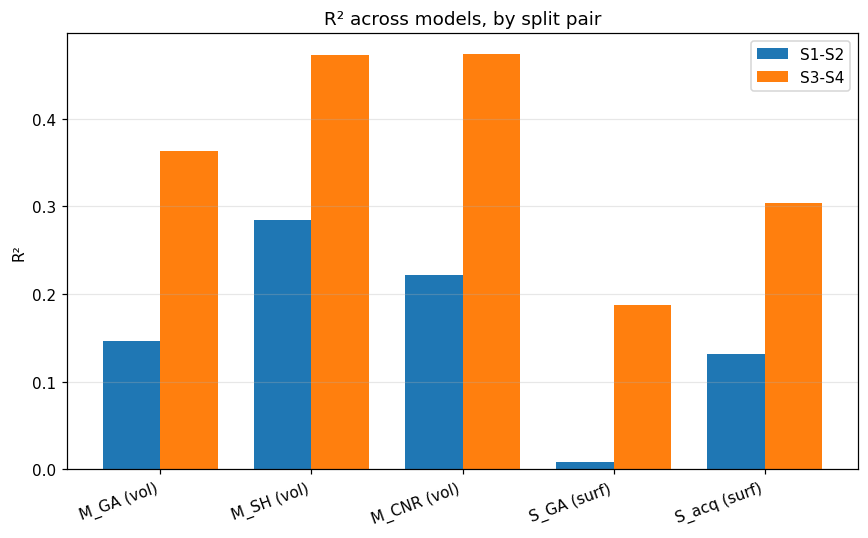

Saved → assets/model_comparison_table.csv, assets/model_comparison_R2.png


In [9]:
all_results = {**vol_results, **surf_results}
comparison = model_comparison_table(all_results)
comparison.to_csv(ASSETS / 'model_comparison_table.csv', index=False)
display(comparison)

# R² bar chart, paired by split
fig, ax = plt.subplots(figsize=(8, 5))
models = comparison['model'].unique()
x = np.arange(len(models))
w = 0.38
for i, pair in enumerate(['S1-S2', 'S3-S4']):
    sub = comparison[comparison['pair'] == pair].set_index('model').reindex(models)
    ax.bar(x + (i - 0.5) * w, sub['R2'], width=w, label=pair)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_ylabel('R²'); ax.set_title('R² across models, by split pair')
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(ASSETS / 'model_comparison_R2.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → assets/model_comparison_table.csv, assets/model_comparison_R2.png')

## Diagnostics — predictions and residuals

For each model, a 2×4 grid:
- **Row 1**: S1-S2  |  **Row 2**: S3-S4
- **Col 1**: Predicted vs Actual (closer to red dashed `y=x` = better fit)
- **Col 2**: Residuals vs Fitted (look for random scatter around 0; funnel shape = heteroscedasticity)
- **Col 3**: QQ-plot of residuals (points on the line = normal residuals; deviations at tails = heavy tails / outliers)
- **Col 4**: Residuals vs GA (look for random scatter; trend = unmodeled GA structure)

Standard interpretation: a *good* model shows random scatter in residual plots and points near the y=x line in predicted-vs-actual.

### Volume — M_GA (baseline)

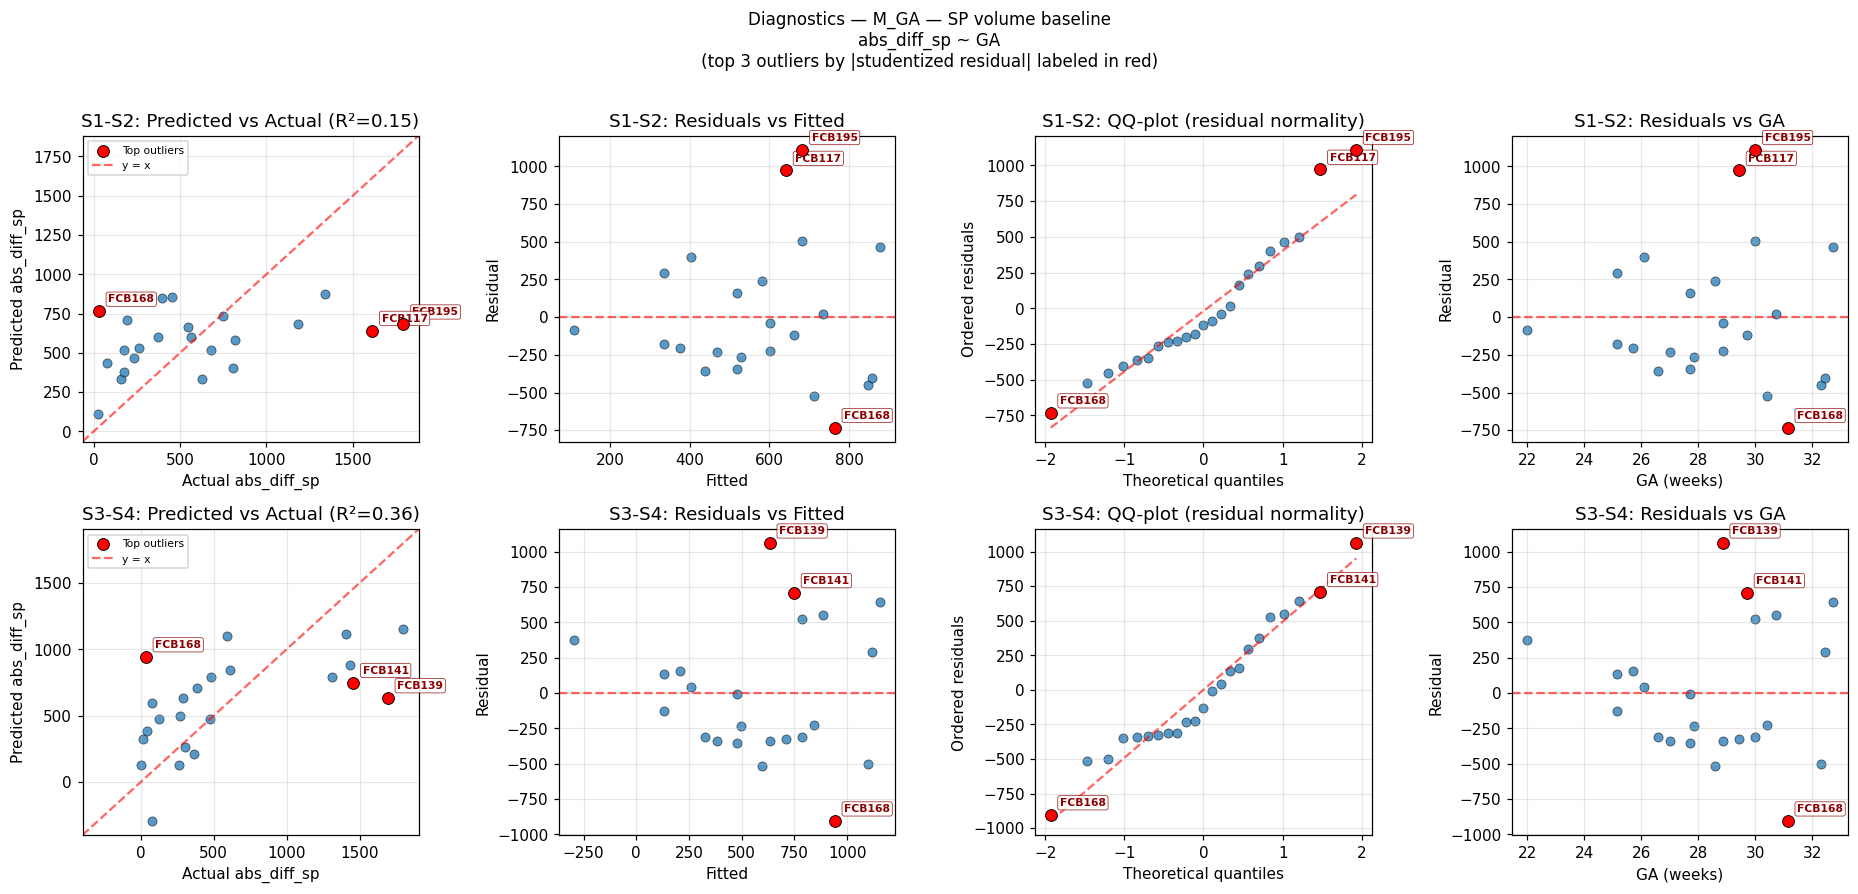

In [10]:
from slides_helpers import diagnostics_grid

diagnostics_grid(
    vol_results['M_GA (vol)'], s12, s34,
    'abs_diff_sp', ['GA'],
    'M_GA — SP volume baseline',
)
plt.show()

### Volume — M_SH

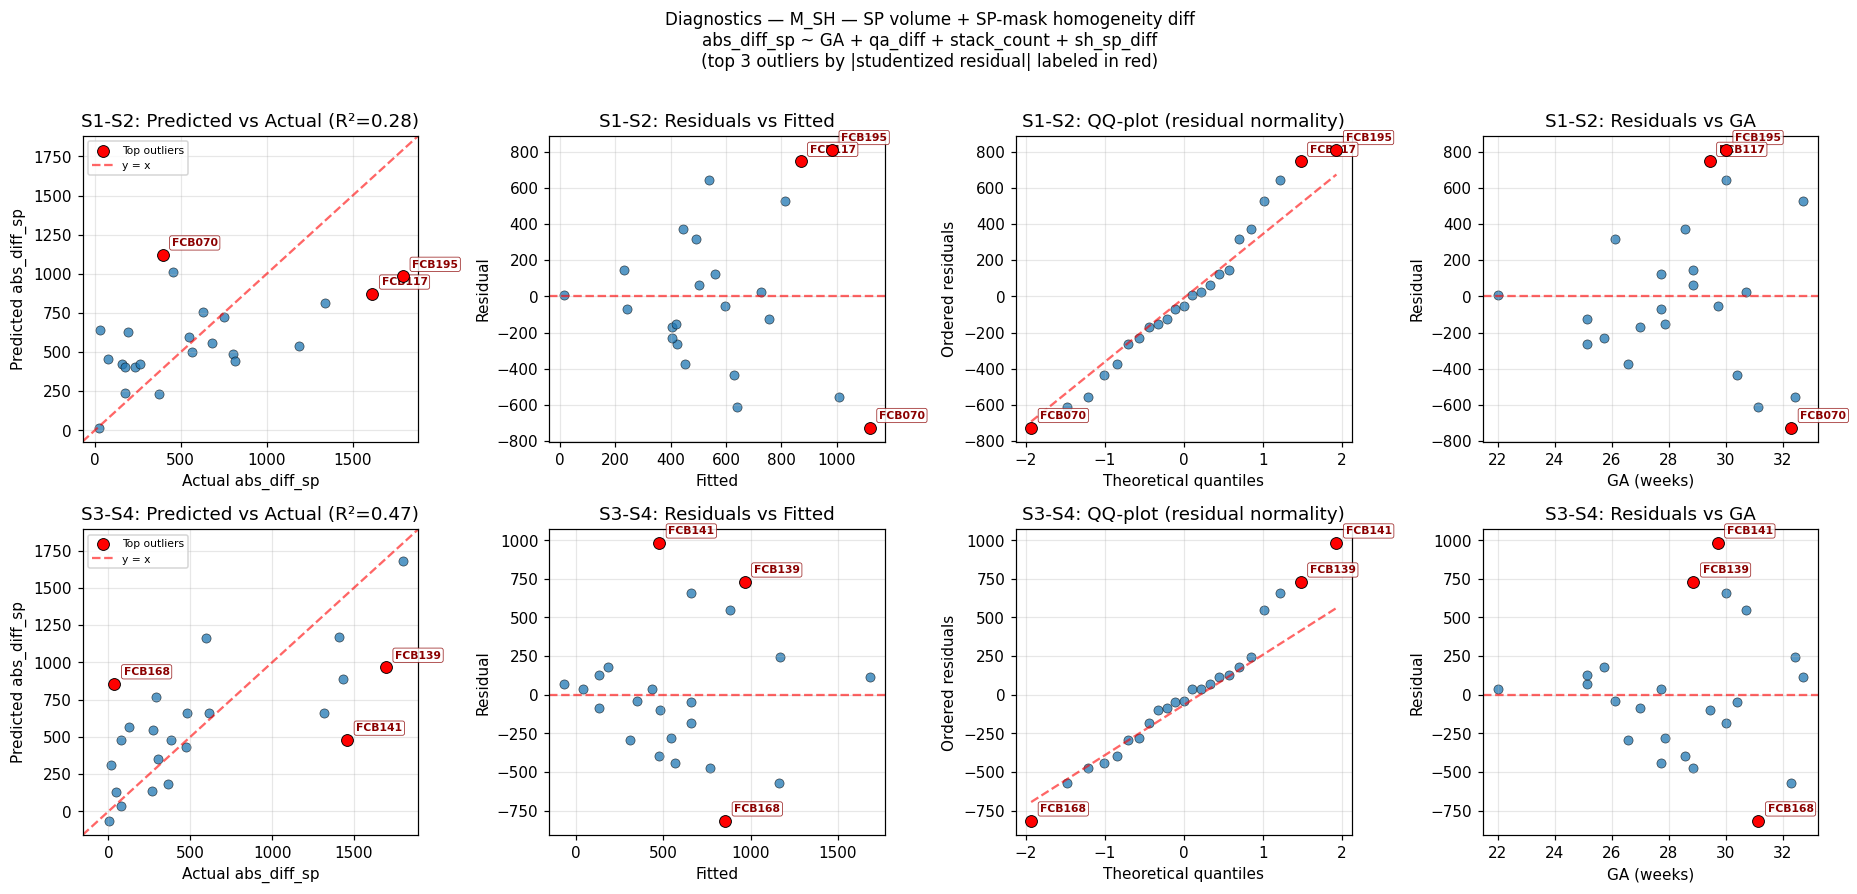

In [11]:
diagnostics_grid(
    vol_results['M_SH (vol)'], s12, s34,
    'abs_diff_sp', ['GA', 'qa_diff', 'stack_count', 'sh_sp_diff'],
    'M_SH — SP volume + SP-mask homogeneity diff',
)
plt.show()

### Volume — M_CNR

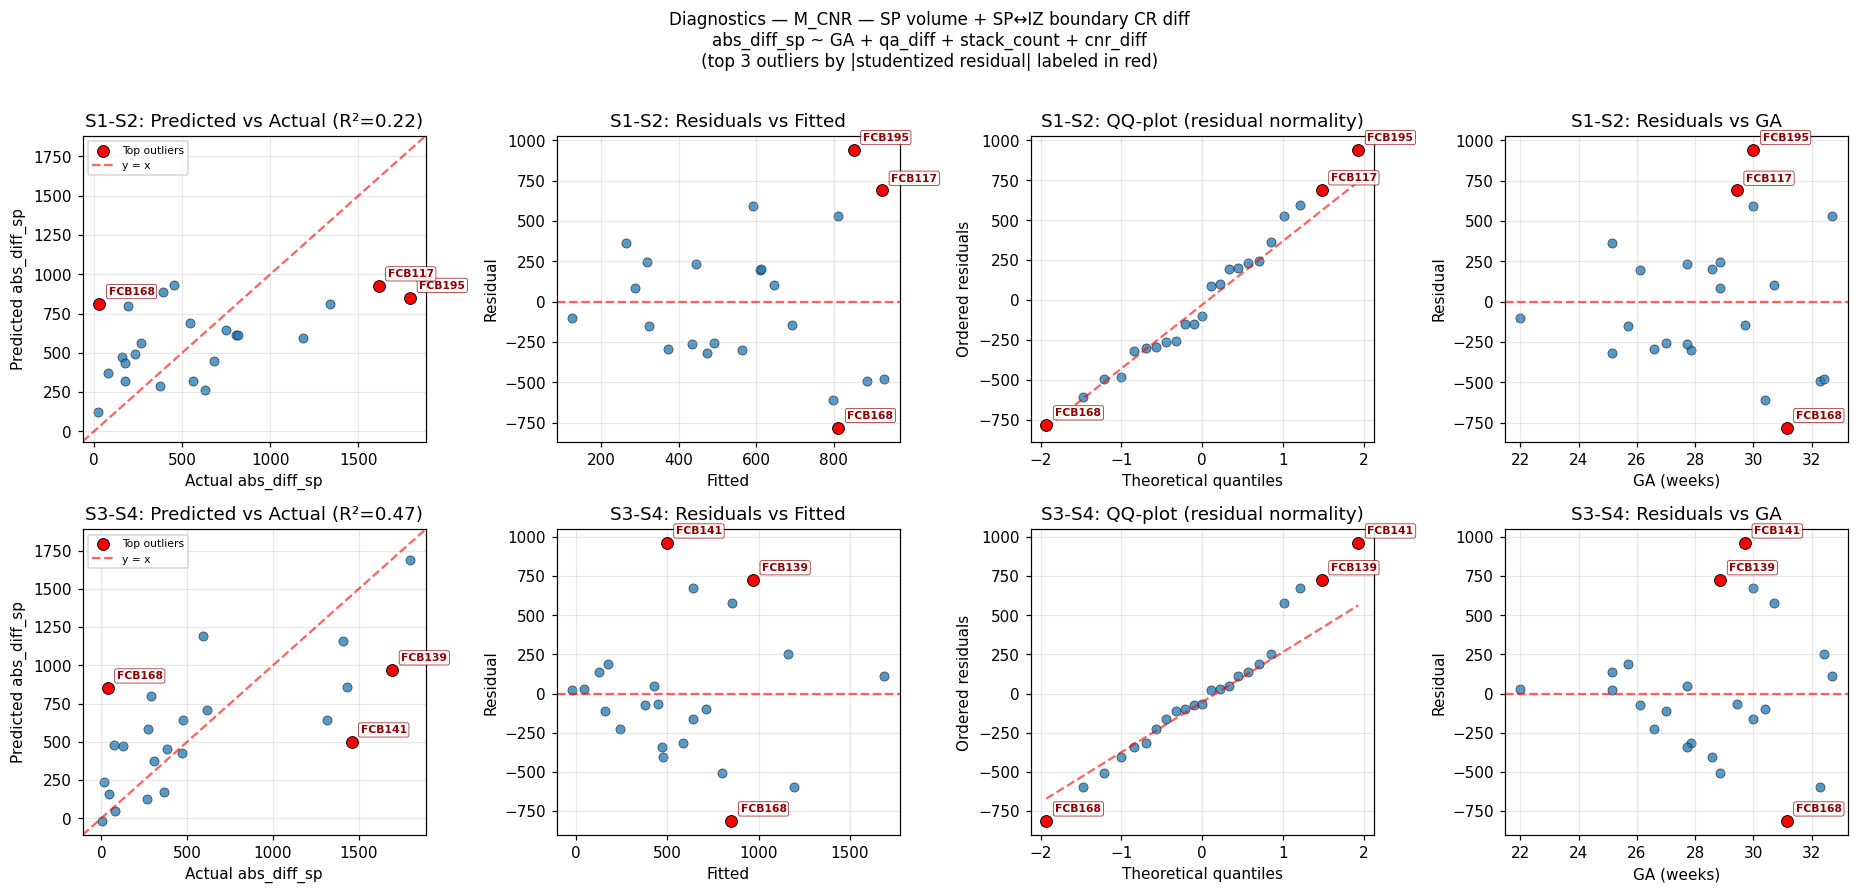

In [12]:
diagnostics_grid(
    vol_results['M_CNR (vol)'], s12, s34,
    'abs_diff_sp', ['GA', 'qa_diff', 'stack_count', 'cnr_diff'],
    'M_CNR — SP volume + SP↔IZ boundary CR diff',
)
plt.show()

### Surface — S_GA (baseline)

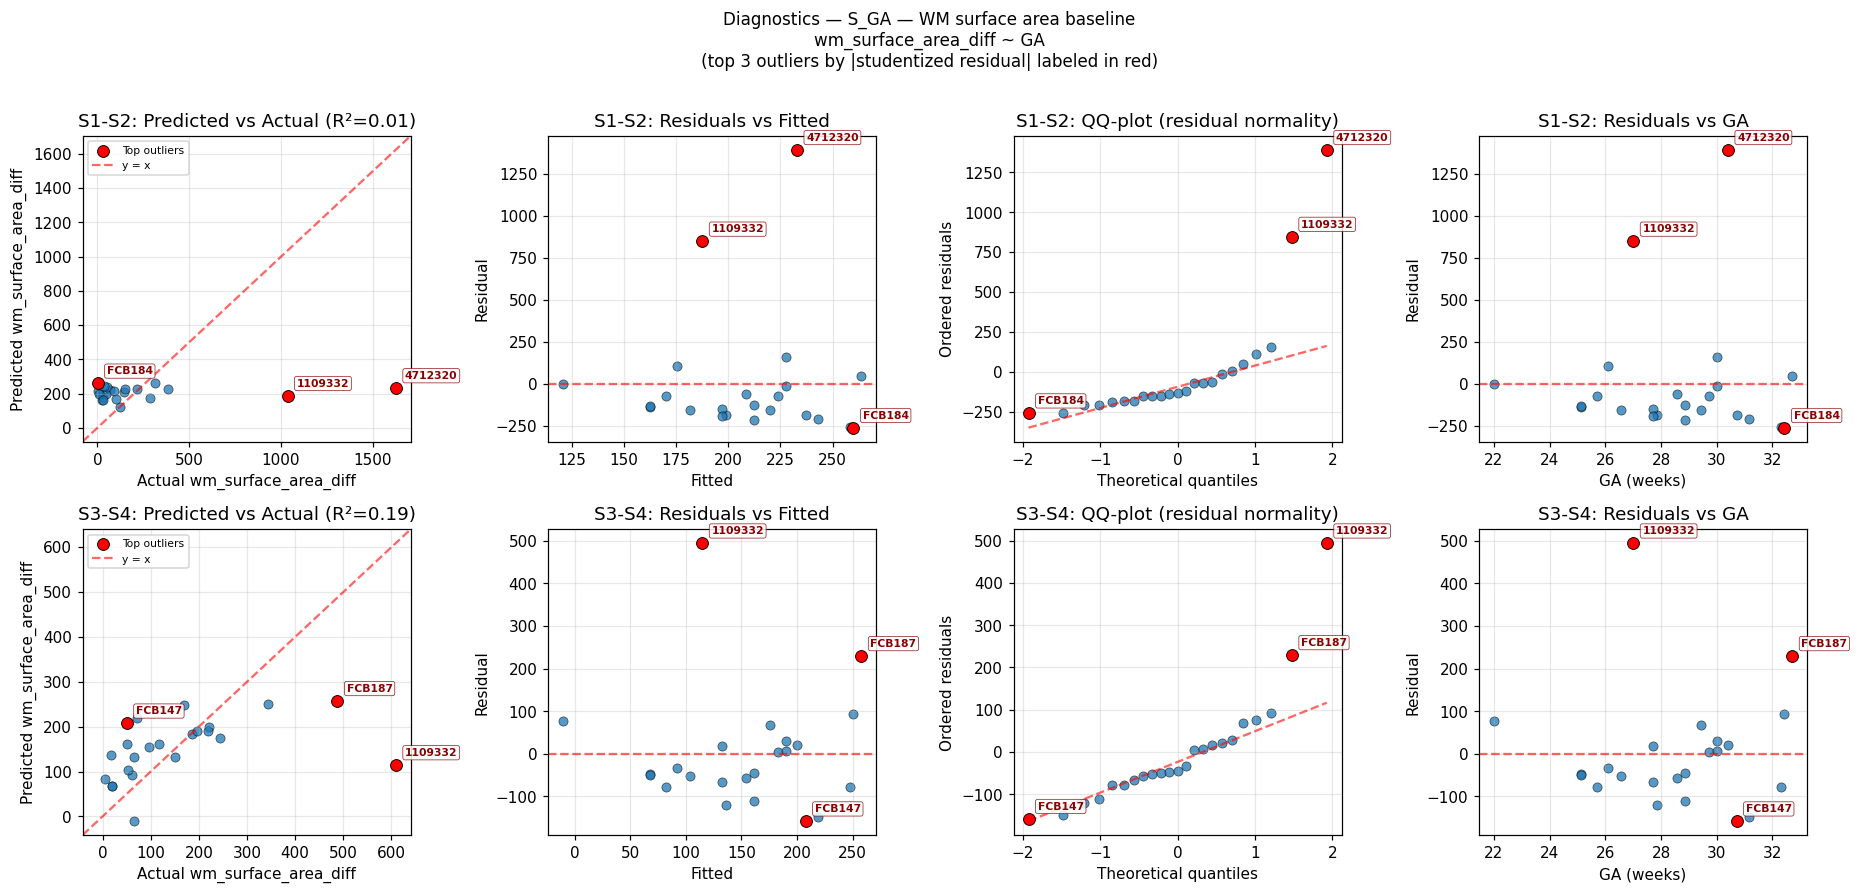

In [13]:
diagnostics_grid(
    surf_results['S_GA (surf)'], s12, s34,
    'wm_surface_area_diff', ['GA'],
    'S_GA — WM surface area baseline',
)
plt.show()

### Surface — S_acq

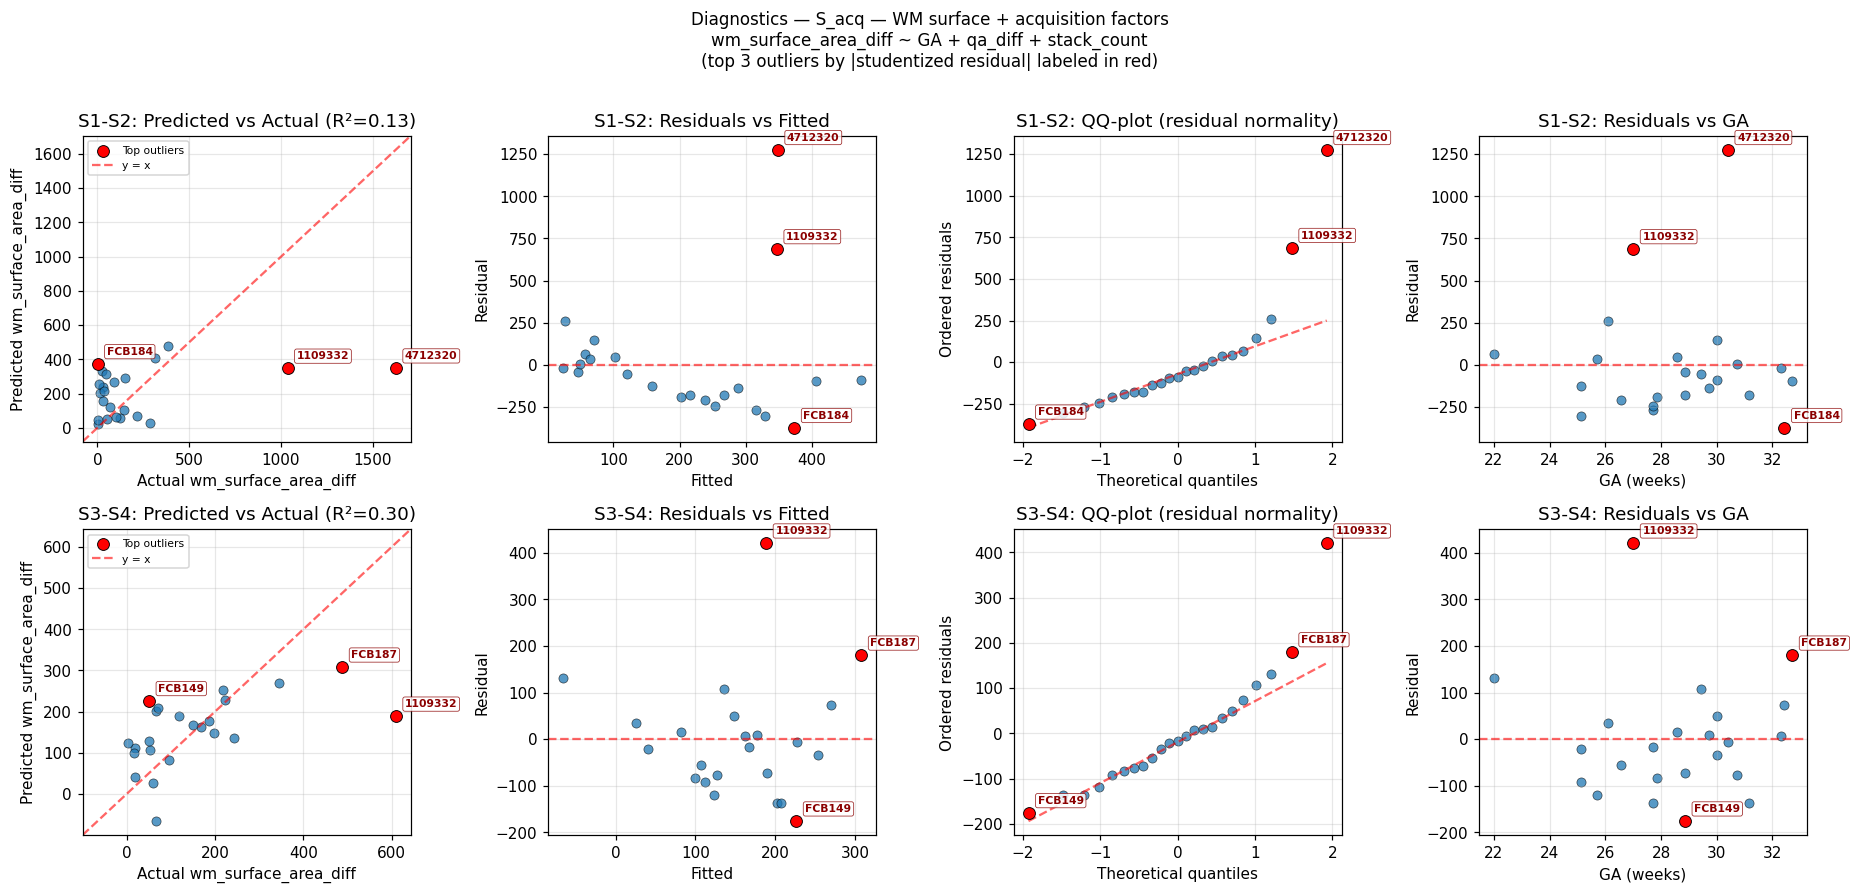

In [14]:
diagnostics_grid(
    surf_results['S_acq (surf)'], s12, s34,
    'wm_surface_area_diff', ['GA', 'qa_diff', 'stack_count'],
    'S_acq — WM surface + acquisition factors',
)
plt.show()